In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from sklearn import metrics

In [20]:
data = datasets.load_digits()

In [21]:
data.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

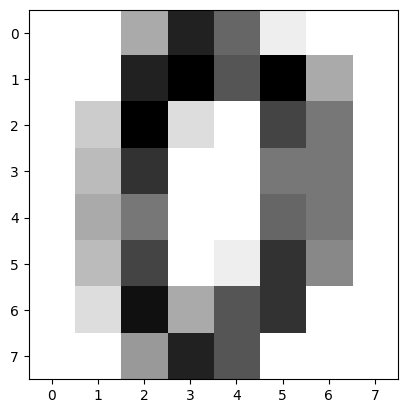

In [22]:
plt.subplot()
plt.imshow(data.images[0], cmap=plt.cm.gray_r)
plt.show()

In [23]:
len(data.images)

1797

In [24]:
x = data.images.reshape((len(data.images), -1))
x

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64))

In [25]:
y = data.target
y

array([0, 1, 2, ..., 8, 9, 8], shape=(1797,))

In [ ]:
ada = AdaBoostClassifier(n_estimators=100, base_estimator=SVC(probability=True, kernel='rbf'))
ada.fit(x[:1000], y[:1000])

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [28]:
p = ada.predict(x[1000:])
e = y[1000:]
print(metrics.classification_report(e, p))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95        79
           1       0.66      0.66      0.66        80
           2       0.81      0.82      0.81        77
           3       0.83      0.73      0.78        79
           4       0.93      0.76      0.83        83
           5       0.89      0.93      0.91        82
           6       0.90      0.75      0.82        80
           7       0.78      0.91      0.84        80
           8       0.66      0.64      0.65        76
           9       0.77      0.91      0.84        81

    accuracy                           0.81       797
   macro avg       0.81      0.81      0.81       797
weighted avg       0.82      0.81      0.81       797



In [29]:
print(metrics.confusion_matrix(e, p))

[[78  0  0  0  0  0  0  1  0  0]
 [ 1 53  2  2  2  1  1  2  3 13]
 [ 1  0 63  7  0  0  0  0  4  2]
 [ 0  2  4 58  0  2  0  3  7  3]
 [ 3  0  0  0 63  0  5 10  0  2]
 [ 2  0  0  2  1 76  1  0  0  0]
 [ 0 13  1  0  0  0 60  0  6  0]
 [ 0  0  0  0  1  0  0 73  5  1]
 [ 0 11  8  1  1  1  0  4 49  1]
 [ 1  1  0  0  0  5  0  0  0 74]]
